# Smart MCQ Solver — Ensemble + W&B Analysis

Combines TF-IDF, LSTM, and DeBERTa submissions into a weighted ensemble, then logs a full analysis to Weights & Biases.

## 1. Install & Login to W&B

In [1]:
!pip install -q wandb


In [2]:
import wandb


from kaggle_secrets import UserSecretsClient
wandb.login(key=UserSecretsClient().get_secret("WANDB_API_KEY"))


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: 23f2004341 (23f2004341-indian-institute-of-technology-madras) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

## 2. Imports

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations


## 3. W&B Run Init + Config

In [4]:
WEIGHTS = {
    "tfidf": 0.10,
    "lstm": 0.00,
    "deberta": 0.90,
}

run = wandb.init(
    project="smart-mcq-solver-challenge",
    name="ensemble-tfidf-lstm-deberta",
    job_type="ensemble",
    config={
        "tfidf_weight": WEIGHTS["tfidf"],
        "lstm_weight": WEIGHTS["lstm"],
        "deberta_weight": WEIGHTS["deberta"],
        "top_k": 3,
        "num_options": 5,
    },
    tags=["ensemble", "tfidf", "lstm", "deberta", "mcq"],
)
cfg = wandb.config


wandb: setting up run g8jg01hz
wandb: Tracking run with wandb version 0.25.1
wandb: Run data is saved locally in /kaggle/working/wandb/run-20260731_134843-g8jg01hz
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run ensemble-tfidf-lstm-deberta
wandb: ⭐️ View project at https://wandb.ai/23f2004341-indian-institute-of-technology-madras/smart-mcq-solver-challenge
wandb: 🚀 View run at https://wandb.ai/23f2004341-indian-institute-of-technology-madras/smart-mcq-solver-challenge/runs/g8jg01hz


## 4. Load Test File

In [5]:
test = pd.read_csv(
    "/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv"
)
test.head()


,id,prompt,A,B,C,D,E
0,1,Pick the best possible answer: What is the rel...,"For every eigenstate of one Hamiltonian, its p...","For every eigenstate of one Hamiltonian, its p...","For every eigenstate of one Hamiltonian, its p...","For every eigenstate of one Hamiltonian, its p...","For every eigenstate of one Hamiltonian, its p..."
1,2,"What is the estimated redshift of CEERS-93316,...","Approximately z = 6.0, corresponding to 1 bill...","Approximately z = 16.7, corresponding to 235.8...","Approximately z = 3.0, corresponding to 5 bill...","Approximately z = 10.0, corresponding to 13 bi...","Approximately z = 13.0, corresponding to 30 bi..."
2,3,Pick the best possible answer: What is the rea...,The sun appears yellowish due to a reflection ...,"The longer wavelengths of light, such as red a...",The sun appears yellowish due to the scatterin...,The sun emits a yellow light due to its own sp...,The atmosphere absorbs the shorter wavelengths...
3,4,What is the significance of the redshift-dista...,Observations of the redshift-distance relation...,Observations of the redshift-distance relation...,Observations of the redshift-distance relation...,Observations of the redshift-distance relation...,Observations of the redshift-distance relation...
4,5,What is the Landau-Lifshitz-Gilbert equation u...,The Landau-Lifshitz-Gilbert equation is a diff...,The Landau-Lifshitz-Gilbert equation is a diff...,The Landau-Lifshitz-Gilbert equation is a diff...,The Landau-Lifshitz-Gilbert equation is a diff...,The Landau-Lifshitz-Gilbert equation is a diff...


## 5. Load Base Model Submissions

In [6]:
tfidf_sub = pd.read_csv(
    "/kaggle/input/notebooks/vishalsharmaaaaaa/02-tfidf/submission.csv"
)

lstm_sub = pd.read_csv(
    "/kaggle/input/notebooks/vishalsharmaaaaaa/03-lstm-ipynb/submission.csv"
)

deberta_sub = pd.read_csv(
    "/kaggle/input/notebooks/vishalsharmaaaaaa/dl-23f2004341-notebook-t22026/submission.csv"
)

print("Loaded:")
print("TFIDF:", len(tfidf_sub))
print("LSTM:", len(lstm_sub))
print("DeBERTa:", len(deberta_sub))

wandb.log({
    "data/n_test": len(test),
    "data/n_tfidf": len(tfidf_sub),
    "data/n_lstm": len(lstm_sub),
    "data/n_deberta": len(deberta_sub),
})


Loaded:
TFIDF: 500
LSTM: 500
DeBERTa: 500


## 6. Detect Prediction Column Names

In [7]:
def get_prediction_column(df):
    for col in df.columns:
        if col.lower() == "prediction":
            return col
    raise ValueError(f"Prediction column not found. Columns = {df.columns}")

tfidf_col = get_prediction_column(tfidf_sub)
lstm_col = get_prediction_column(lstm_sub)
deberta_col = get_prediction_column(deberta_sub)


## 7. Ensemble Weights

In [8]:
TFIDF_WEIGHT = cfg.tfidf_weight
LSTM_WEIGHT = cfg.lstm_weight
DEBERTA_WEIGHT = cfg.deberta_weight


## 8. Build the Weighted Ensemble

Also tracks each model's top-1 pick and the ensemble score margin, for the analysis section below.

In [9]:
final_predictions = []
tfidf_top1_list, lstm_top1_list, deberta_top1_list, ensemble_top1_list = [], [], [], []
score_margins = []  # gap between rank-1 and rank-2 score, per row

for i in range(len(test)):

    tfidf_pred = str(tfidf_sub.iloc[i][tfidf_col]).split()
    lstm_pred = str(lstm_sub.iloc[i][lstm_col]).split()
    deberta_pred = str(deberta_sub.iloc[i][deberta_col]).split()

    tfidf_top1_list.append(tfidf_pred[0] if tfidf_pred else None)
    lstm_top1_list.append(lstm_pred[0] if lstm_pred else None)
    deberta_top1_list.append(deberta_pred[0] if deberta_pred else None)

    option_scores = {"A": 0.0, "B": 0.0, "C": 0.0, "D": 0.0, "E": 0.0}

    for rank, option in enumerate(tfidf_pred):
        option_scores[option] += TFIDF_WEIGHT * (3 - rank)

    for rank, option in enumerate(lstm_pred):
        option_scores[option] += LSTM_WEIGHT * (3 - rank)

    for rank, option in enumerate(deberta_pred):
        option_scores[option] += DEBERTA_WEIGHT * (3 - rank)

    ranked = sorted(option_scores.items(), key=lambda x: x[1], reverse=True)
    top3 = [o for o, s in ranked[:3]]

    final_predictions.append(" ".join(top3))
    ensemble_top1_list.append(top3[0])
    score_margins.append(ranked[0][1] - ranked[1][1])


## 9. Save Submission

In [10]:
submission = pd.DataFrame({
    "id": test["id"],
    "prediction": final_predictions,
})

submission.to_csv("/kaggle/working/submission.csv", index=False)

print("\nSubmission Saved Successfully")
print(submission.head())
print("\nFile Location:")
print("/kaggle/working/submission.csv")



Submission Saved Successfully
   id prediction
0   1      A C E
1   2      B E D
2   3      B E D
3   4      E C A
4   5      C D A

File Location:
/kaggle/working/submission.csv


## 10. Build Analysis DataFrame

In [11]:
analysis_df = pd.DataFrame({
    "id": test["id"],
    "tfidf_top1": tfidf_top1_list,
    "lstm_top1": lstm_top1_list,
    "deberta_top1": deberta_top1_list,
    "ensemble_top1": ensemble_top1_list,
    "ensemble_top3": final_predictions,
    "score_margin": score_margins,
})
analysis_df.head()


,id,tfidf_top1,lstm_top1,deberta_top1,ensemble_top1,ensemble_top3,score_margin
0,1,A,A,A,A,A C E,1.1
1,2,B,B,B,B,B E D,1.0
2,3,B,B,B,B,B E D,1.0
3,4,E,E,E,E,E C A,1.0
4,5,C,C,C,C,C D A,1.2


## 11. Top-1 Distribution per Model

/tmp/ipykernel_23/1552784909.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, ax=ax, palette="viridis")
/tmp/ipykernel_23/1552784909.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, ax=ax, palette="viridis")
/tmp/ipykernel_23/1552784909.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, ax=ax, palette="viridis")
/tmp/ipykernel_23/1552784909.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed

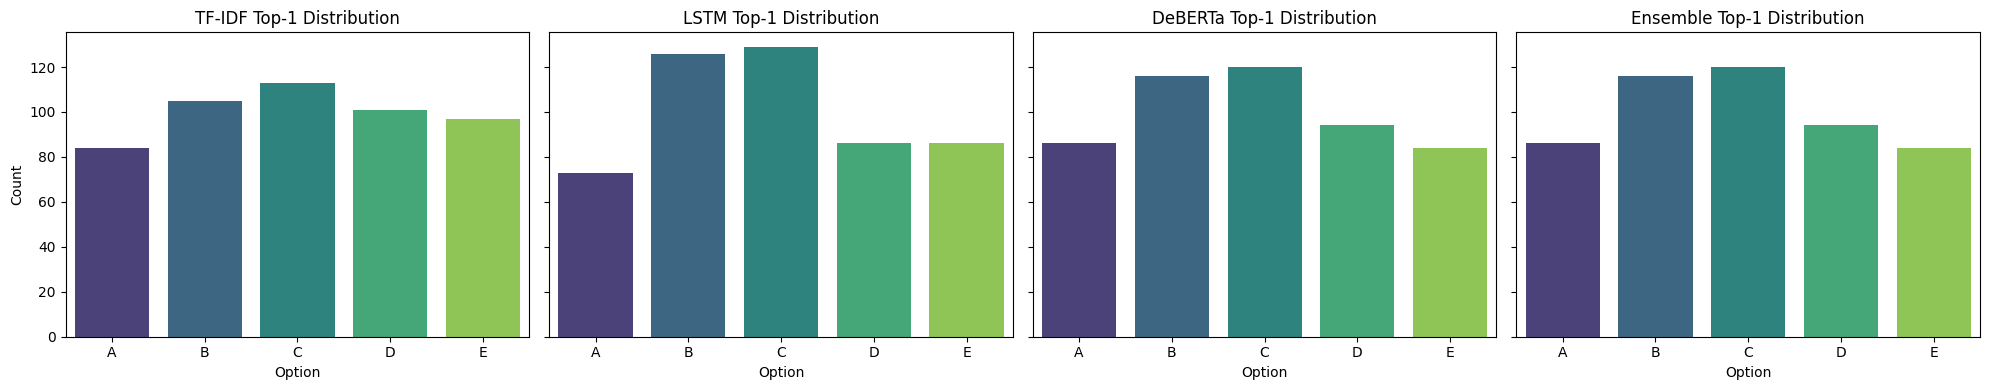

In [12]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4), sharey=True)
for ax, col, title in zip(
    axes,
    ["tfidf_top1", "lstm_top1", "deberta_top1", "ensemble_top1"],
    ["TF-IDF", "LSTM", "DeBERTa", "Ensemble"],
):
    order = ["A", "B", "C", "D", "E"]
    counts = analysis_df[col].value_counts().reindex(order, fill_value=0)
    sns.barplot(x=counts.index, y=counts.values, ax=ax, palette="viridis")
    ax.set_title(f"{title} Top-1 Distribution")
    ax.set_xlabel("Option")
    ax.set_ylabel("Count")
plt.tight_layout()
wandb.log({"charts/top1_distribution": wandb.Image(fig)})
plt.show()


## 12. Pairwise Model Agreement (Top-1)

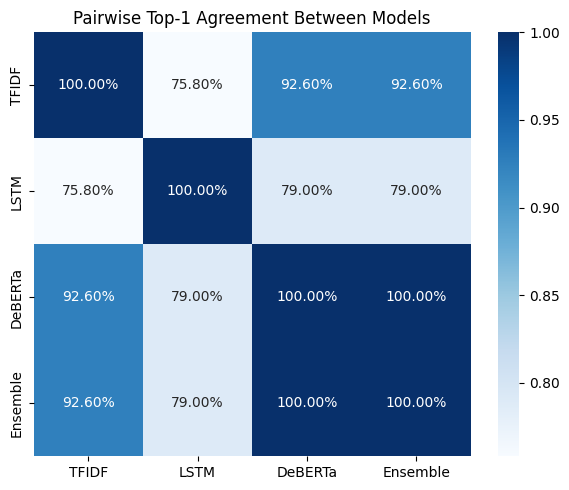

In [13]:
models = {
    "TFIDF": tfidf_top1_list,
    "LSTM": lstm_top1_list,
    "DeBERTa": deberta_top1_list,
    "Ensemble": ensemble_top1_list,
}
model_names = list(models.keys())
agreement_matrix = np.zeros((len(model_names), len(model_names)))

for i, m1 in enumerate(model_names):
    for j, m2 in enumerate(model_names):
        a = np.array(models[m1])
        b = np.array(models[m2])
        agreement_matrix[i, j] = (a == b).mean()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    agreement_matrix,
    annot=True,
    fmt=".2%",
    xticklabels=model_names,
    yticklabels=model_names,
    cmap="Blues",
    ax=ax,
)
ax.set_title("Pairwise Top-1 Agreement Between Models")
plt.tight_layout()
wandb.log({"charts/model_agreement_heatmap": wandb.Image(fig)})
plt.show()

for m1, m2 in combinations(model_names, 2):
    key = f"agreement/{m1.lower()}_vs_{m2.lower()}"
    a = np.array(models[m1])
    b = np.array(models[m2])
    wandb.log({key: float((a == b).mean())})


## 13. Base Learner vs Ensemble Agreement

In [14]:
tfidf_vs_ensemble = float((analysis_df["tfidf_top1"] == analysis_df["ensemble_top1"]).mean())
lstm_vs_ensemble = float((analysis_df["lstm_top1"] == analysis_df["ensemble_top1"]).mean())
deberta_vs_ensemble = float((analysis_df["deberta_top1"] == analysis_df["ensemble_top1"]).mean())

wandb.log({
    "agreement/tfidf_vs_ensemble": tfidf_vs_ensemble,
    "agreement/lstm_vs_ensemble": lstm_vs_ensemble,
    "agreement/deberta_vs_ensemble": deberta_vs_ensemble,
})

print("TFIDF vs Ensemble:", tfidf_vs_ensemble)
print("LSTM vs Ensemble:", lstm_vs_ensemble)
print("DeBERTa vs Ensemble:", deberta_vs_ensemble)


TFIDF vs Ensemble: 0.926
LSTM vs Ensemble: 0.79
DeBERTa vs Ensemble: 1.0


## 14. Score Margin (Confidence Proxy) Distribution

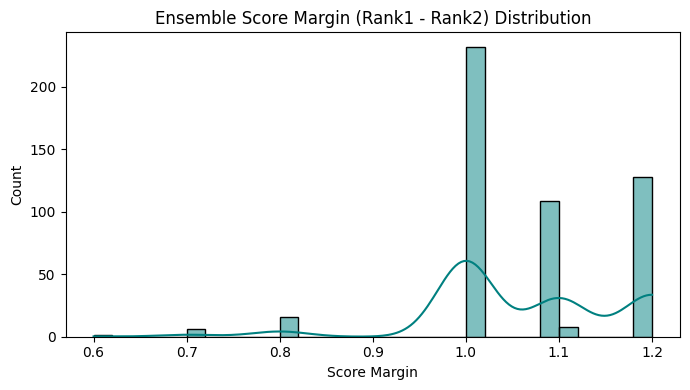

In [15]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.histplot(analysis_df["score_margin"], bins=30, kde=True, ax=ax, color="teal")
ax.set_title("Ensemble Score Margin (Rank1 - Rank2) Distribution")
ax.set_xlabel("Score Margin")
plt.tight_layout()
wandb.log({"charts/score_margin_distribution": wandb.Image(fig)})
plt.show()

wandb.log({
    "margin/mean": float(np.mean(score_margins)),
    "margin/median": float(np.median(score_margins)),
    "margin/std": float(np.std(score_margins)),
    "margin/pct_low_confidence_lt_0.2": float((np.array(score_margins) < 0.2).mean()),
})


## 15. Base-Model Consensus Analysis

/tmp/ipykernel_23/2222275420.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=unanimity_counts.index.astype(str), y=unanimity_counts.values, ax=ax, palette="rocket")


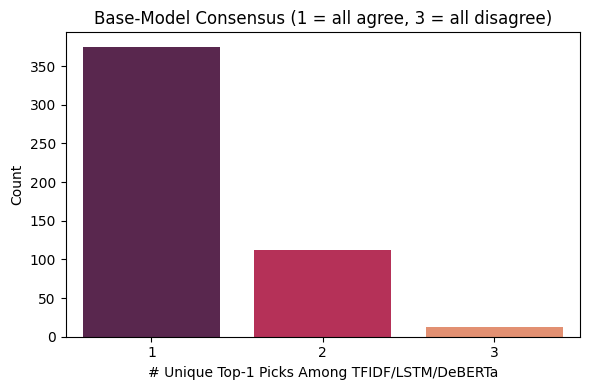

In [16]:
def unanimity(row):
    votes = {row["tfidf_top1"], row["lstm_top1"], row["deberta_top1"]}
    return len(votes)

analysis_df["n_unique_votes"] = analysis_df.apply(unanimity, axis=1)
unanimity_counts = analysis_df["n_unique_votes"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(x=unanimity_counts.index.astype(str), y=unanimity_counts.values, ax=ax, palette="rocket")
ax.set_title("Base-Model Consensus (1 = all agree, 3 = all disagree)")
ax.set_xlabel("# Unique Top-1 Picks Among TFIDF/LSTM/DeBERTa")
ax.set_ylabel("Count")
plt.tight_layout()
wandb.log({"charts/consensus_distribution": wandb.Image(fig)})
plt.show()

wandb.log({
    "consensus/pct_unanimous": float((analysis_df["n_unique_votes"] == 1).mean()),
    "consensus/pct_full_split": float((analysis_df["n_unique_votes"] == 3).mean()),
})


## 16. Log Sample Predictions Table to W&B

In [17]:
sample_table = wandb.Table(dataframe=analysis_df.sample(min(50, len(analysis_df)), random_state=42))
wandb.log({"tables/sample_predictions": sample_table})


## 17. Log Submission + Analysis as W&B Artifacts

In [18]:
analysis_df.to_csv("/kaggle/working/analysis_df.csv", index=False)

sub_artifact = wandb.Artifact("submission", type="submission")
sub_artifact.add_file("/kaggle/working/submission.csv")
run.log_artifact(sub_artifact)

analysis_artifact = wandb.Artifact("prediction_analysis", type="analysis")
analysis_artifact.add_file("/kaggle/working/analysis_df.csv")
run.log_artifact(analysis_artifact)


<Artifact prediction_analysis>

## 18. Run Summary + Finish

In [19]:
wandb.summary["n_rows"] = len(submission)
wandb.summary["tfidf_weight"] = TFIDF_WEIGHT
wandb.summary["lstm_weight"] = LSTM_WEIGHT
wandb.summary["deberta_weight"] = DEBERTA_WEIGHT
wandb.summary["mean_score_margin"] = float(np.mean(score_margins))
wandb.summary["pct_unanimous_consensus"] = float((analysis_df["n_unique_votes"] == 1).mean())

wandb.finish()

print("W&B logging complete. Check your run dashboard for charts, tables, and artifacts.")


wandb: updating run metadata; uploading artifact run-g8jg01hz-tablessample_predictions-IyToMA; uploading artifact submission; uploading media/images/charts/top1_distribution_1_6a5351334d5d03613780.png; uploading media/images/charts/model_agreement_heatmap_2_504e8660acbb6317d371.png (+ 6 more)
wandb: uploading artifact run-g8jg01hz-tablessample_predictions-IyToMA; uploading artifact submission; uploading artifact prediction_analysis
wandb: uploading artifact submission; uploading artifact prediction_analysis
wandb: uploading artifact prediction_analysis
wandb: uploading history steps 0-14, summary, console lines 3-42
wandb: 
wandb: Run history:
wandb: agreement/deberta_vs_ensemble ▁▁
wandb:     agreement/lstm_vs_deberta ▁
wandb:    agreement/lstm_vs_ensemble ▁▁
wandb:    agreement/tfidf_vs_deberta ▁
wandb:   agreement/tfidf_vs_ensemble ▁▁
wandb:       agreement/tfidf_vs_lstm ▁
wandb:      consensus/pct_full_split ▁
wandb:       consensus/pct_unanimous ▁
wandb:                data/n_debe

W&B logging complete. Check your run dashboard for charts, tables, and artifacts.
